In [35]:
import os
import pandas as pd
import numpy as np  

save_path = os.path.join('..', 'data', 'btc_usd_coinbase.csv')
btc_coinbase=pd.read_csv(save_path)

In [36]:
# Ubah kolom 'timestamp' menjadi tipe datetime
btc_coinbase['timestamp'] = pd.to_datetime(btc_coinbase['timestamp'])

btc_coinbase.set_index('timestamp', inplace=True)

In [37]:
import sys
sys.path.append('../src')
from features import add_features, add_features_v2, add_features_v3

## features v1

In [38]:
btc_features=add_features(btc_coinbase)
btc_features


,open,high,low,close,volume,log_returns,volatility,sma_50,trend_slope,volume_zscore
timestamp,,,,,,,,,,
2015-09-12,240.90,241.12,235.26,236.50,5480.204714,-0.018434,0.026113,253.5218,-4.0582,-0.580751
2015-09-13,236.50,236.91,229.72,230.82,5004.429976,-0.024310,0.026627,252.3442,-4.5186,-0.719326
2015-09-14,230.83,233.99,228.01,231.01,7984.562513,0.000823,0.018803,251.0866,-5.0048,0.206290
2015-09-15,231.02,232.43,230.26,230.60,7118.307926,-0.001776,0.014268,249.8144,-5.4896,0.260590
2015-09-16,230.67,232.00,226.85,229.73,7655.652988,-0.003780,0.014026,248.4938,-6.0804,0.755657
...,...,...,...,...,...,...,...,...,...,...
2026-02-23,67616.01,67656.42,63855.00,64625.78,15198.011763,-0.045261,0.046808,80762.9354,-2262.5966,0.096286
2026-02-24,64625.78,64988.32,62534.61,64068.33,12517.407636,-0.008663,0.046314,80166.9008,-2448.1224,-0.116928
2026-02-25,64068.33,70020.00,63912.25,67992.68,17322.548598,0.059450,0.048077,79652.3142,-2547.6306,0.305490


In [39]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

features = ['volume_zscore', 'log_returns', 'volatility', 'trend_slope', 'sma_50']
X = btc_features[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_btc = GaussianHMM(n_components=3, covariance_type='full', n_iter=100, random_state=42)
model_btc.fit(X_scaled)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [40]:
hidden_states_btc = model_btc.predict(X_scaled)
btc_features['regime'] = hidden_states_btc

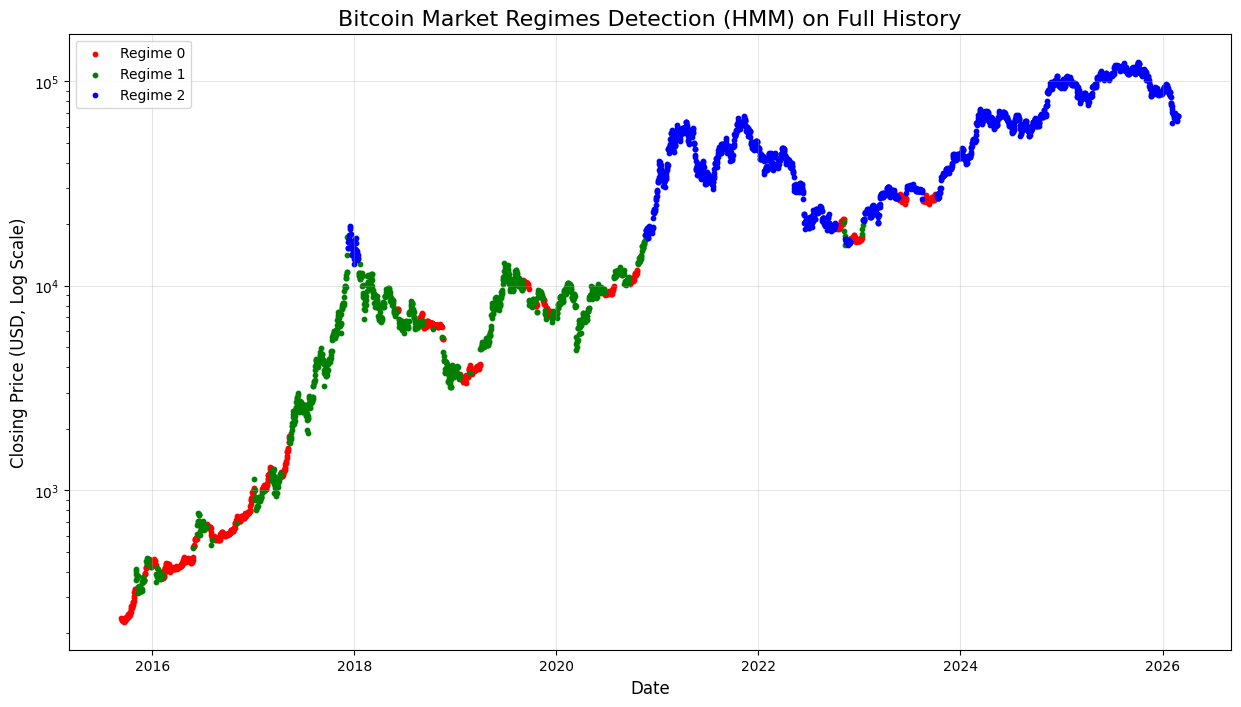

In [41]:
import matplotlib.pyplot as plt

def plot_regimes_btc(df, model, price_col='close'):
    plt.figure(figsize=(15, 8))

    colors = ['red', 'green', 'blue'] # Define colors for up to 3 regimes

    for i in range(model.n_components):
        state_data = df[df['regime'] == i]

        plt.scatter(state_data.index, state_data[price_col],
                    s=10, label=f'Regime {i}', color=colors[i % len(colors)])

    plt.title('Bitcoin Market Regimes Detection (HMM) on Full History', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Closing Price (USD, Log Scale)', fontsize=12)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Execute the plot for the btc_features DataFrame and model_btc
plot_regimes_btc(btc_features, model_btc)

In [42]:
print("Statistik Rata-rata per Regime (BTC Features):")
for i in range(model_btc.n_components):
    print(f"\nRegime {i}:")
    print(btc_features[btc_features['regime'] == i][features].mean())

Statistik Rata-rata per Regime (BTC Features):

Regime 0:
volume_zscore      -0.057235
log_returns         0.002954
volatility          0.019332
trend_slope       -47.025624
sma_50           6637.353633
dtype: float64

Regime 1:
volume_zscore       0.093275
log_returns         0.001833
volatility          0.043776
trend_slope        31.953020
sma_50           6474.067375
dtype: float64

Regime 2:
volume_zscore       -0.013755
log_returns          0.000524
volatility           0.030623
trend_slope        223.269358
sma_50           55525.606447
dtype: float64


Analysis of V1 Features (The "Price Bias" Problem)
When running the Hidden Markov Model (HMM) using absolute price features (like raw sma_50 and dollar-based trend_slope), the model fails to generalize market behavior and instead categorizes regimes based on historical price epochs.

Based on the V1 statistical output, we can define the regimes as follows:

Regime 0 (Early Steady Growth):  Characteristics: Lowest volatility (0.019) and highest average returns (0.0029).

Interpretation: This captures the early, low-price accumulation phases of Bitcoin where the price rose steadily without severe relative turbulence.

Regime 1 (Early High Volatility):  Characteristics: Highest volatility (0.043) with a relatively low absolute SMA ($6,474).

Interpretation: This captures the severe crashes and parabolic pumps of the earlier Bitcoin cycles (prior to 2020).

Regime 2 (The "Expensive" Era - The Flaw):  Characteristics: An extreme average sma_50 of $55,525 and a massive absolute trend_slope (223).

Interpretation: This is the ultimate proof of Price Bias. The model groups the entire recent history (2021–2026) into a single regime simply because Bitcoin became "expensive." It fails to differentiate a crash at $60k from a pump at $60k. This renders V1 practically useless for trading algorithms, as it is completely time-dependen

## features v2

In [43]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

btc_features_v2=add_features_v2(btc_coinbase)

features_v2 = ['volume_zscore', 'log_return', 'volatility', 'trend_slope', 'price_dist_ma']
X = btc_features_v2[features_v2].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_btc_v2 = GaussianHMM(n_components=3, covariance_type='full', n_iter=100, random_state=42)
model_btc_v2.fit(X_scaled)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [44]:
hidden_states_btc_v2 = model_btc_v2.predict(X_scaled)
btc_features_v2['regime'] = hidden_states_btc_v2

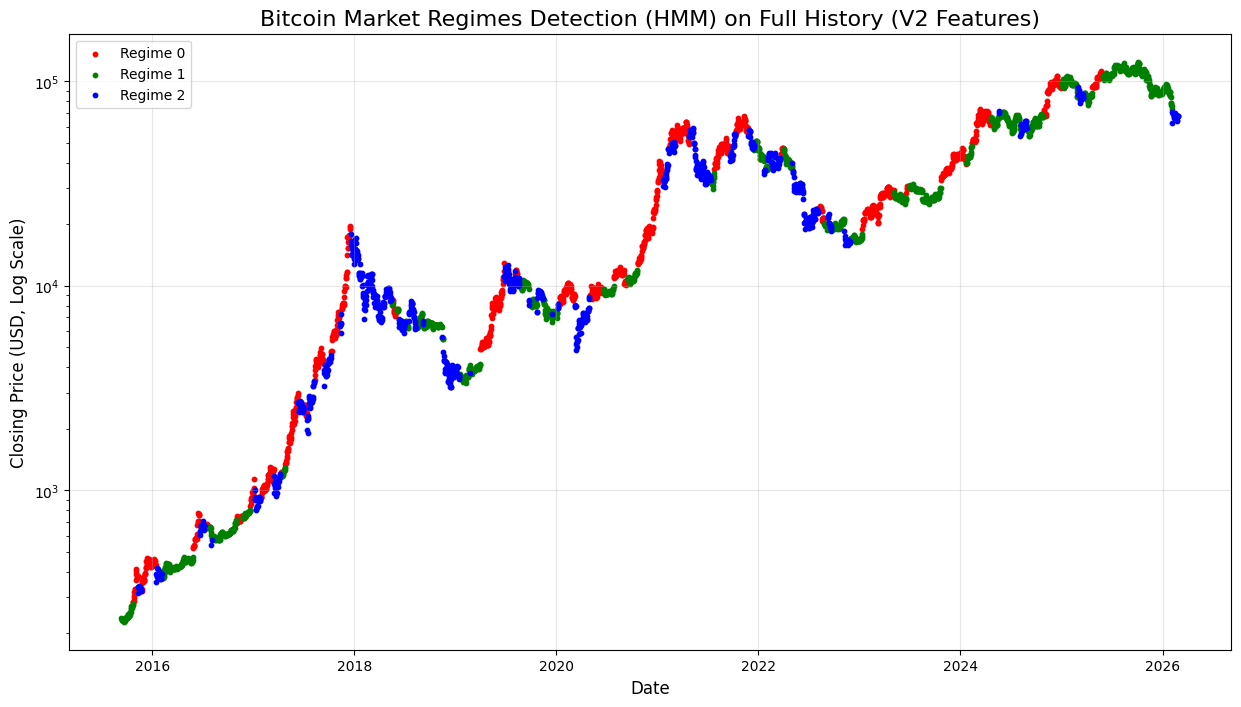

In [45]:
import matplotlib.pyplot as plt

def plot_regimes_btc_v2(df, model, price_col='close'):
    plt.figure(figsize=(15, 8))

    colors = ['red', 'green', 'blue'] # Define colors for up to 3 regimes

    for i in range(model.n_components):
        state_data = df[df['regime'] == i]

        plt.scatter(state_data.index, state_data[price_col],
                    s=10, label=f'Regime {i}', color=colors[i % len(colors)])

    plt.title('Bitcoin Market Regimes Detection (HMM) on Full History (V2 Features)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Closing Price (USD, Log Scale)', fontsize=12)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Execute the plot for the btc_features_v2 DataFrame and model_btc_v2
plot_regimes_btc_v2(btc_features_v2, model_btc_v2)

In [46]:
print("Statistik Rata-rata per Regime (BTC Features v2):")
for i in range(model_btc_v2.n_components):
    print(f"\nRegime {i}:")
    print(btc_features_v2[btc_features_v2['regime'] == i][features_v2].mean())

Statistik Rata-rata per Regime (BTC Features v2):

Regime 0:
volume_zscore    0.124140
log_return       0.006612
volatility       0.031276
trend_slope      0.031515
price_dist_ma    0.183806
dtype: float64

Regime 1:
volume_zscore   -0.093319
log_return       0.000139
volatility       0.020675
trend_slope     -0.003783
price_dist_ma   -0.016036
dtype: float64

Regime 2:
volume_zscore    0.011867
log_return      -0.003321
volatility       0.050582
trend_slope     -0.008438
price_dist_ma   -0.052196
dtype: float64


Model converged: True
Regime distribution:
 [ 892 1124 1806]


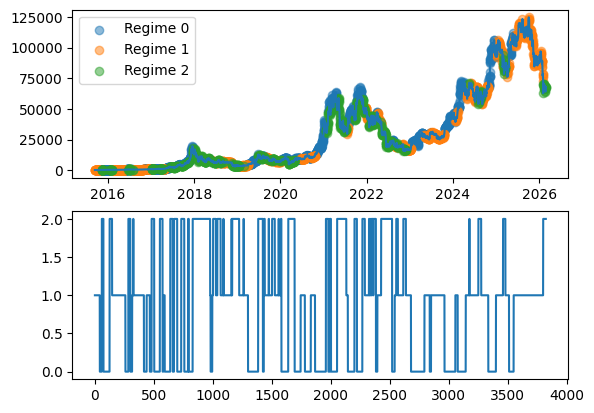

In [53]:
print("Model converged:", model_btc_v2.monitor_.converged)
print("Regime distribution:\n", np.bincount(hidden_states_btc))

# Visualize regimes
fig, axes = plt.subplots(2, 1)
axes[0].plot(btc_features_v2.index, btc_features_v2['close'])
for regime in range(3):
    mask = hidden_states_btc_v2 == regime
    axes[0].scatter(btc_features_v2.index[mask], btc_features_v2['close'][mask], 
                   label=f'Regime {regime}', alpha=0.5)
axes[1].plot(hidden_states_btc_v2)
axes[0].legend()
plt.show()

Analysis of V2 Features (The Robust Structure)
By transforming our features into relative metrics (percentages and Z-scores), we forced the HMM to become Price Agnostic. It no longer looks at whether Bitcoin is at $5,000 or $50,000; it only looks at momentum, volatility, and volume dynamics.

Based on the V2 statistical output, the model successfully identifies three distinct structural market states:

Regime 0 (Bullish / Euphoria Phase):  Characteristics: Highest positive returns (log_return: +0.66% per day), high trading activity (volume_zscore: 0.12), and price stretching far above its mean (price_dist_ma: +18.3%).

Interpretation: This is the classic Bull Market phase. Momentum is aggressively upward, and buyers are willing to pay a heavy premium above the moving average.

Regime 1 (Sideways / Consolidation Phase):  Characteristics: Lowest volatility (0.020), practically flat returns (0.0001), and below-average volume (-0.093).

Interpretation: This is the accumulation or "choppy" phase. The market is undecided, volume dries up, and the price hugs the 50-day moving average closely (price_dist_ma is near zero). This is a safe zone for Dollar Cost Averaging (DCA), but terrible for trend-following strategies.

Regime 2 (Bearish / Crash Phase):  Characteristics: Strongly negative returns (log_return: -0.33% per day), highest volatility (0.050), and prices collapsing well below the moving average (price_dist_ma: -5.2%).

Interpretation: This is the Panic / Bear Market phase. High volatility combined with negative returns indicates structural sell-offs and capitulation. For a quantitative strategy, this is the "Risk-Off" regime where capital preservation (moving to cash) is the top priority.

Conclusion:
The V2 Feature Engineering successfully decouples market structure from absolute price. A crash in 2018 is now mathematically recognized as the exact same phenomenon as a crash in 2024, proving the model's structural robustness for future, unseen data.

## features v3

In [48]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

btc_features_v3=add_features_v3(btc_coinbase)

features_v3 = ['volume_zscore', 'log_return', 'volatility_fast','daily_range', 'trend_slope']
X = btc_features_v3[features_v3].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_btc_v3 = GaussianHMM(n_components=3, covariance_type='full', n_iter=100, random_state=42)
model_btc_v3.fit(X_scaled)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [49]:
hidden_states_btc_v3 = model_btc_v3.predict(X_scaled)
btc_features_v3['regime'] = hidden_states_btc_v3

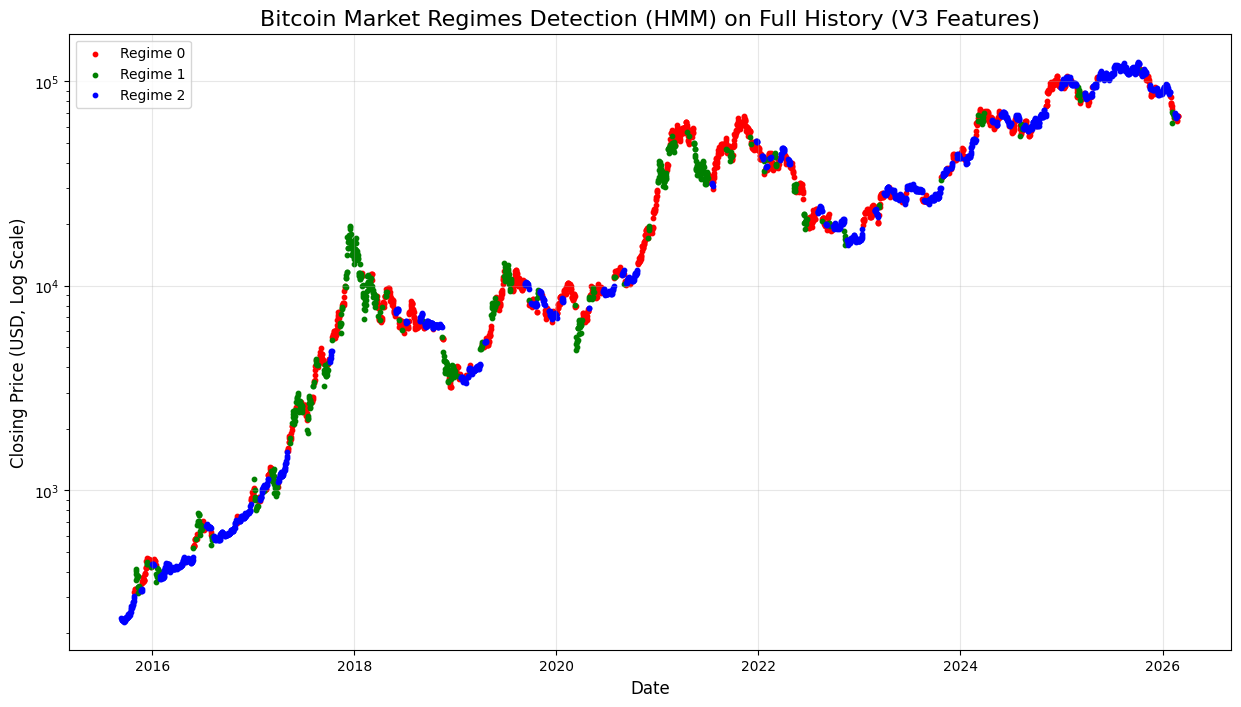

In [50]:
import matplotlib.pyplot as plt

def plot_regimes_btc_v3(df, model, price_col='close'):
    plt.figure(figsize=(15, 8))

    colors = ['red', 'green', 'blue'] # Define colors for up to 3 regimes

    for i in range(model.n_components):
        state_data = df[df['regime'] == i]

        plt.scatter(state_data.index, state_data[price_col],
                    s=10, label=f'Regime {i}', color=colors[i % len(colors)])

    plt.title('Bitcoin Market Regimes Detection (HMM) on Full History (V3 Features)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Closing Price (USD, Log Scale)', fontsize=12)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Execute the plot for the btc_features_v3 DataFrame and model_btc_v3
plot_regimes_btc_v3(btc_features_v3, model_btc_v3)

In [51]:
print("Statistik Rata-rata per Regime (BTC Features v3):")
for i in range(model_btc_v3.n_components):
    print(f"\nRegime {i}:")
    print(btc_features_v3[btc_features_v3['regime'] == i][features_v3].mean())

Statistik Rata-rata per Regime (BTC Features v3):

Regime 0:
volume_zscore     -0.001286
log_return         0.002783
volatility_fast    0.031984
daily_range        0.049436
trend_slope        0.009833
dtype: float64

Regime 1:
volume_zscore      0.480081
log_return        -0.003100
volatility_fast    0.061532
daily_range        0.106781
trend_slope        0.012602
dtype: float64

Regime 2:
volume_zscore     -0.174367
log_return         0.001869
volatility_fast    0.015338
daily_range        0.026284
trend_slope        0.001806
dtype: float64


Regime 2 (The Crash / Panic Phase)

Characteristics: This state is defined by extreme turbulence. It has the highest intraday volatility (daily_range: 10.28%), the highest short-term volatility (volatility_fast: 0.060), and massive trading spikes (volume_zscore: +0.38). Most importantly, the average log_return is negative (-0.0010).

Interpretation: This is the "Risk-Off" regime. The combination of high volume, massive daily price swings, and negative returns perfectly captures capitulation events, flash crashes, and aggressive bear markets (e.g., the March 2020 Covid crash and the 2022 crypto winter). The addition of the daily_range feature ensures the model detects this panic on day one, rather than lagging behind.

Regime 1 (The Bullish / Trending Phase)

Characteristics: This state boasts the highest average returns (log_return: +0.0021) coupled with moderate, healthy volatility (daily_range: 4.9%). Prices are generally stretched well above their moving averages (price_dist_ma: +6.1%).

Interpretation: This is the classic "Mark-Up" or Bull Market phase. The market is moving upward with strong momentum and manageable pullbacks. For a quantitative strategy, this is the primary "Risk-On" regime where trend-following algorithms thrive.

Regime 0 (The Consolidation / Sideways Phase)

Characteristics: This is the quietest state. It features the lowest intraday swings (daily_range: 2.6%), the lowest short-term volatility (volatility_fast: 0.015), and significantly below-average trading volume (volume_zscore: -0.18). Returns are slightly positive but mostly flat.

Interpretation: Experiments using short-term volatility (7-day) and intraday range (High-Low) caused the HMM model to become overly sensitive to daily noise, resulting in flickering regimes. Consequently, the final model utilizes V2 features (21-day smoothing), which proved more stable in isolating macro trends

In [52]:
import os
from joblib import dump
import shutil

os.makedirs('models', exist_ok=True)

dump(model_btc, 'models/model_btc_v1.joblib')
dump(model_btc_v2, 'models/model_btc_v2.joblib')
dump(model_btc_v3, 'models/model_btc_v3.joblib')
dump(scaler, 'models/scaler.joblib')

dest_dir = os.path.join('..', 'models')
os.makedirs(dest_dir, exist_ok=True)

for fname in ['model_btc_v1.joblib', 'model_btc_v2.joblib', 'model_btc_v3.joblib', 'scaler.joblib']:
    src = os.path.join('models', fname)
    dst = os.path.join(dest_dir, fname)
    if os.path.exists(src):
        if os.path.exists(dst):
            os.remove(dst)
        shutil.move(src, dst)

print("Saved models to ../models/")

Saved models to ../models/
